<a href="https://colab.research.google.com/github/ayush-142005/Major_SOC_SOH_Estimation/blob/main/SOH_estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## SOH Estimation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import os
import seaborn as sns

## Load Dataset

In [ ]:
b1 = pd.read_csv(r'/content/drive/MyDrive/SOH Dataset/B05_discharge_soh.csv')
b1

,terminal_voltage,terminal_current,temperature,charge_current,charge_voltage,time,capacity,cycle,SOH
0,4.191492,-0.004902,24.330034,-0.0006,0.000,0.000,1.856487,1,0.928244
1,4.190749,-0.001478,24.325993,-0.0006,4.206,16.781,1.856487,1,0.928244
2,3.974871,-2.012528,24.389085,-1.9982,3.062,35.703,1.856487,1,0.928244
3,3.951717,-2.013979,24.544752,-1.9982,3.030,53.781,1.856487,1,0.928244
4,3.934352,-2.011144,24.731385,-1.9982,3.011,71.922,1.856487,1,0.928244
...,...,...,...,...,...,...,...,...,...
50280,3.579262,-0.001569,34.864823,0.0006,0.000,2781.312,1.325079,168,0.662540
50281,3.581964,-0.003067,34.814770,0.0006,0.000,2791.062,1.325079,168,0.662540
50282,3.584484,-0.003079,34.676258,0.0006,0.000,2800.828,1.325079,168,0.662540
50283,3.587336,0.001219,34.565580,0.0006,0.000,2810.640,1.325079,168,0.662540


In [ ]:
b2 = pd.read_csv(r'/content/drive/MyDrive/SOH Dataset/B07_discharge_soh.csv')
b3 = pd.read_csv(r'/content/drive/MyDrive/SOH Dataset/B18_discharge_soh.csv')
b4 = pd.read_csv(r'/content/drive/MyDrive/SOH Dataset/B33_discharge_soh.csv')
b5 = pd.read_csv(r'/content/drive/MyDrive/SOH Dataset/B34_discharge_soh.csv')
b6 = pd.read_csv(r'/content/drive/MyDrive/SOH Dataset/B46_discharge_soh.csv')
b7 = pd.read_csv(r'/content/drive/MyDrive/SOH Dataset/B47_discharge_soh.csv')
b8 = pd.read_csv(r'/content/drive/MyDrive/SOH Dataset/B48_discharge_soh.csv')

In [ ]:
print ("Battery 1" +str(np.shape(b1)))
print ("Battery 2" +str(np.shape(b2)))
print ("Battery 3" +str(np.shape(b3)))
print ("Battery 4" +str(np.shape(b4)))
print ("Battery 5" +str(np.shape(b5)))
print ("Battery 6" +str(np.shape(b6)))
print ("Battery 7" +str(np.shape(b7)))
print ("Battery 8" +str(np.shape(b8)))

Battery 1(50285, 9)
Battery 2(50285, 9)
Battery 3(34866, 9)
Battery 4(47065, 9)
Battery 5(47065, 9)
Battery 6(24519, 9)
Battery 7(24519, 9)
Battery 8(24519, 9)


In [ ]:
b1.columns

Index(['terminal_voltage', 'terminal_current', 'temperature', 'charge_current',
       'charge_voltage', 'time', 'capacity', 'cycle', 'SOH'],
      dtype='object')

In [ ]:
print("Battery 1")
print(b1.describe())
print()
print("Battery 2")
print(b2.describe())
print()
print("Battery 3")
print(b3.describe())
print()
print("Battery 4")
print(b4.describe())
print()
print("Battery 5")
print(b5.describe())
print()
print("Battery 6")
print(b6.describe())
print()
print("Battery 7")
print(b7.describe())
print()
print("Battery 8")
print(b8.describe())
print()


Battery 1
       terminal_voltage  terminal_current   temperature  charge_current  \
count      50285.000000      50285.000000  50285.000000    50285.000000   
mean           3.515268         -1.806032     32.816991        1.362700   
std            0.231778          0.610502      3.987515        1.313698   
min            2.455679         -2.029098     23.214802       -1.998400   
25%            3.399384         -2.013415     30.019392        1.998000   
50%            3.511664         -2.012312     32.828944        1.998200   
75%            3.660903         -2.011052     35.920887        1.998200   
max            4.222920          0.007496     41.450232        1.998400   

       charge_voltage          time      capacity         cycle           SOH  
count    50285.000000  50285.000000  50285.000000  50285.000000  50285.000000  
mean         2.308406   1546.208924      1.560345     88.125942      0.780172  
std          0.800300    906.640295      0.182380     45.699687      0.091

## About Dataset


*   Battery 1

State of Health ($\text{SOH}$): The $\text{SOH}$ degraded substantially, dropping from a maximum of $\approx 94.6\%$ to a minimum of $\approx 70.0\%$.<br>
Capacity Loss: The measured capacity decreased from a maximum of $\approx 1.89\text{ Ah}$ to a minimum of $\approx 1.40\text{ Ah}$
<br>
*   Battery 2


## Visualization of Capacity vs Cycle

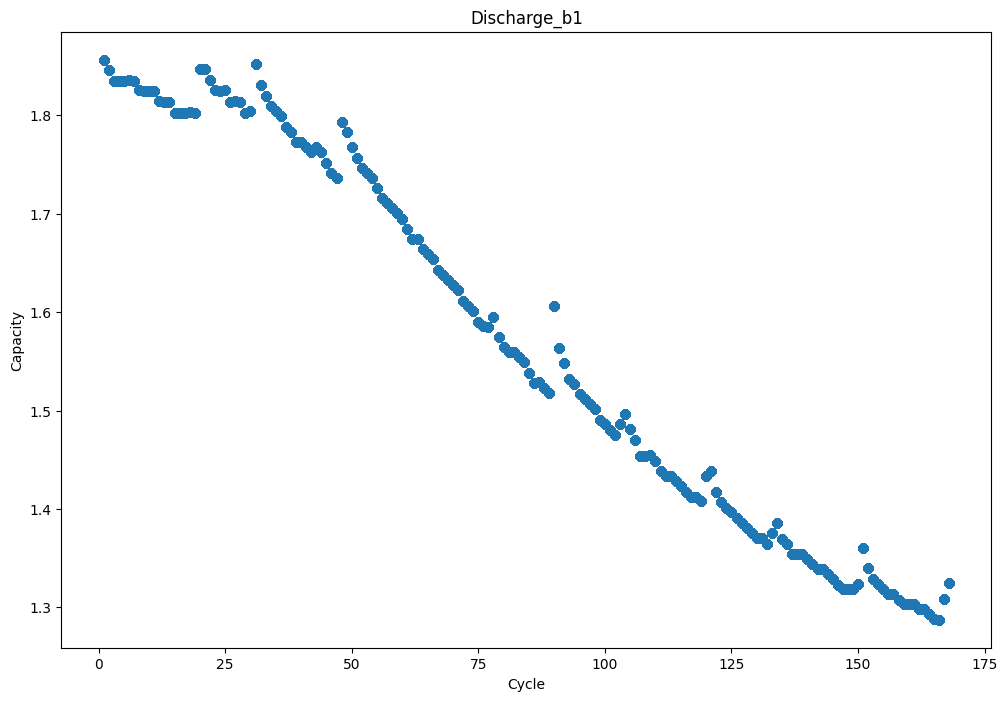

In [ ]:
plt.figure(figsize=(12,8))
plt.scatter(b1['cycle'],b1['capacity'])
plt.ylabel('Capacity')
plt.xlabel('Cycle')
plt.title('Discharge_b1')
plt.show()

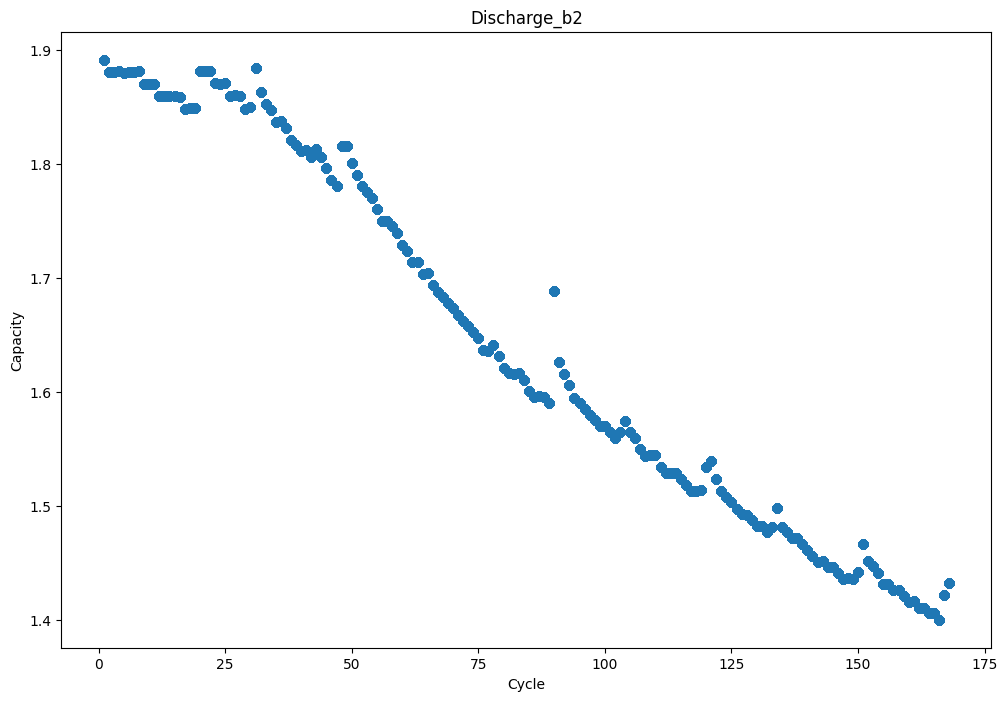

In [ ]:
plt.figure(figsize=(12,8))
plt.scatter(b2['cycle'],b2['capacity'])
plt.ylabel('Capacity')
plt.xlabel('Cycle')
plt.title('Discharge_b2')
plt.show()

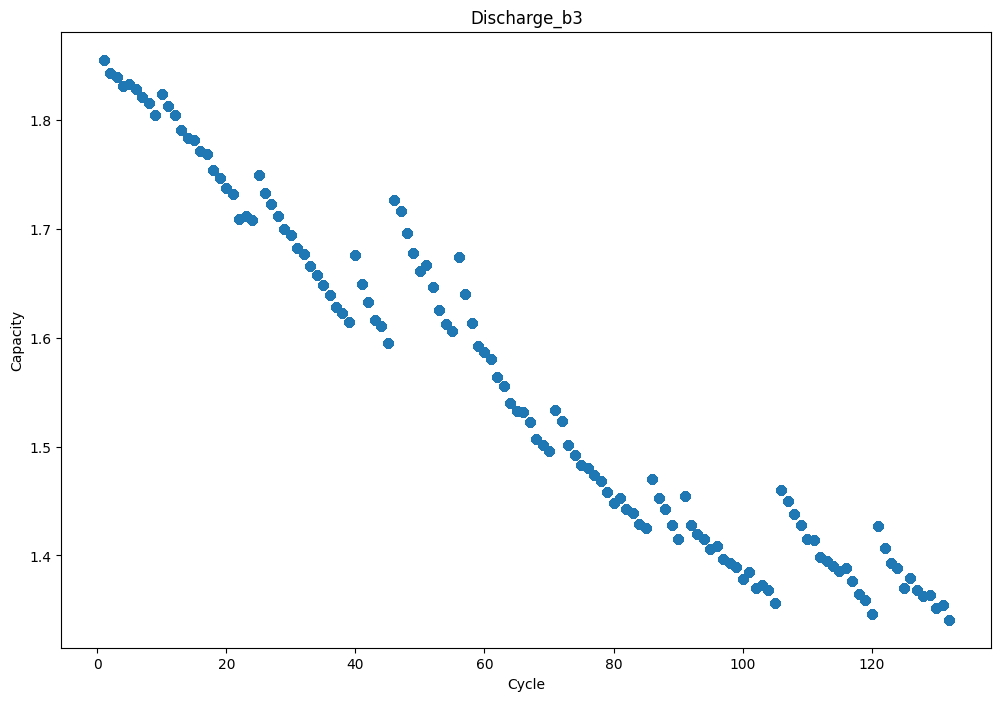

In [ ]:
plt.figure(figsize=(12,8))
plt.scatter(b3['cycle'],b3['capacity'])
plt.ylabel('Capacity')
plt.xlabel('Cycle')
plt.title('Discharge_b3')
plt.show()

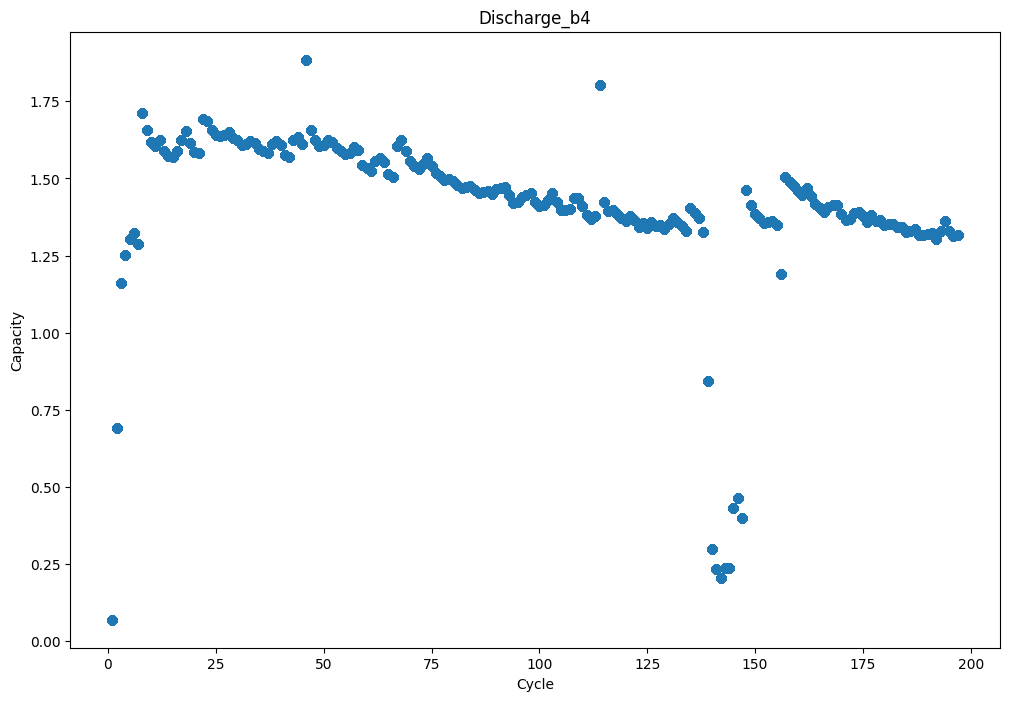

In [ ]:
plt.figure(figsize=(12,8))
plt.scatter(b4['cycle'],b4['capacity'])
plt.ylabel('Capacity')
plt.xlabel('Cycle')
plt.title('Discharge_b4')
plt.show()

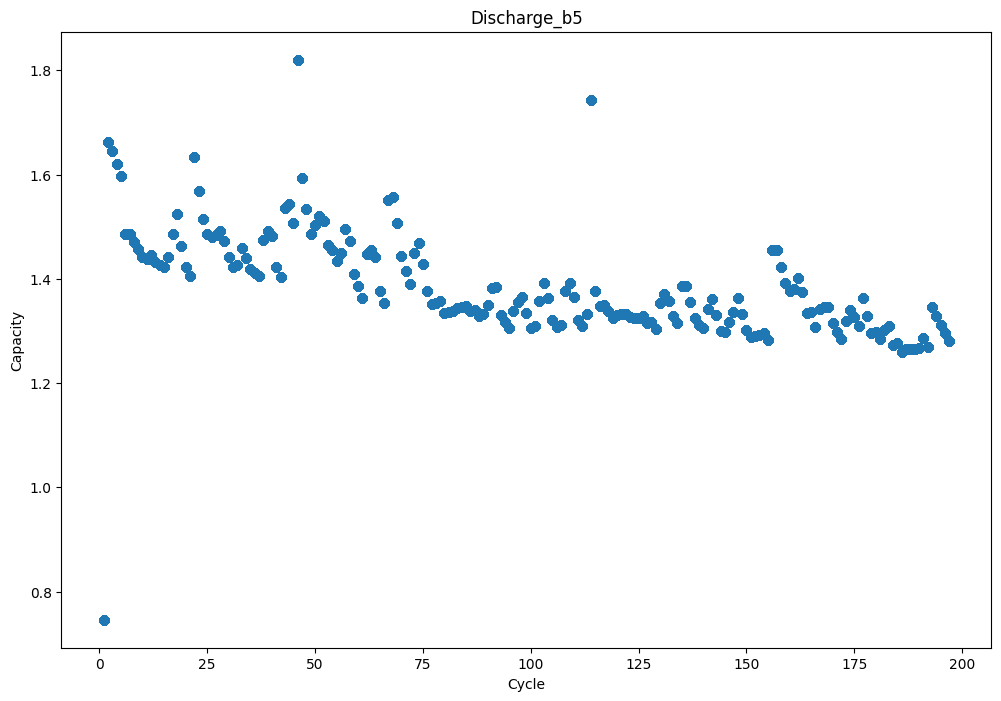

In [ ]:
plt.figure(figsize=(12,8))
plt.scatter(b5['cycle'],b5['capacity'])
plt.ylabel('Capacity')
plt.xlabel('Cycle')
plt.title('Discharge_b5')
plt.show()

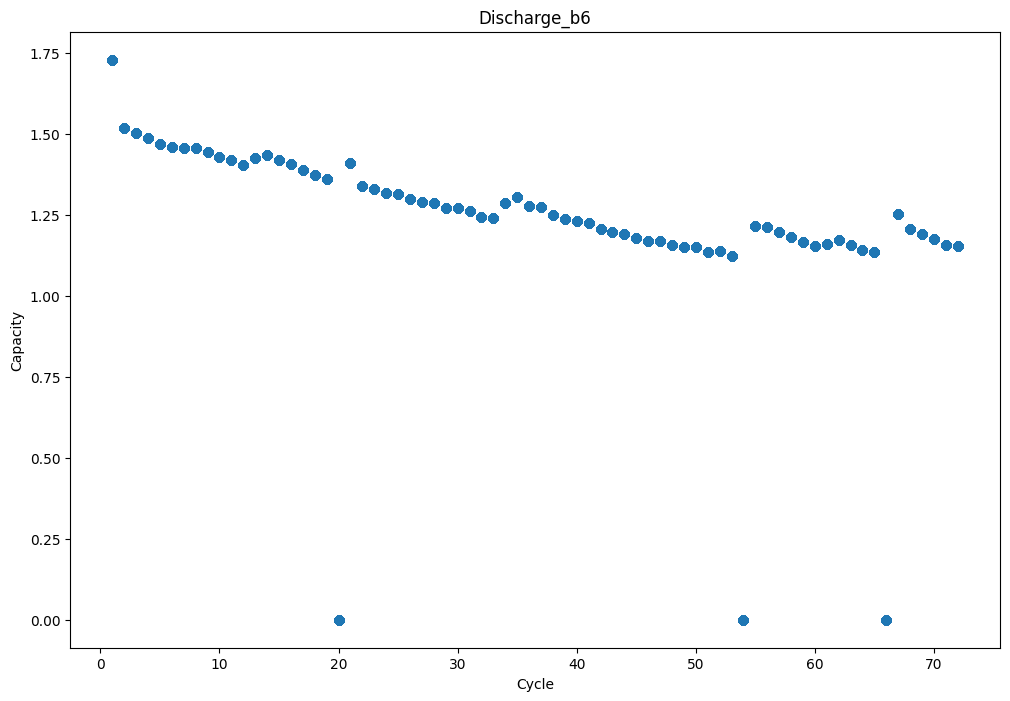

In [ ]:
plt.figure(figsize=(12,8))
plt.scatter(b6['cycle'],b6['capacity'])
plt.ylabel('Capacity')
plt.xlabel('Cycle')
plt.title('Discharge_b6')
plt.show()

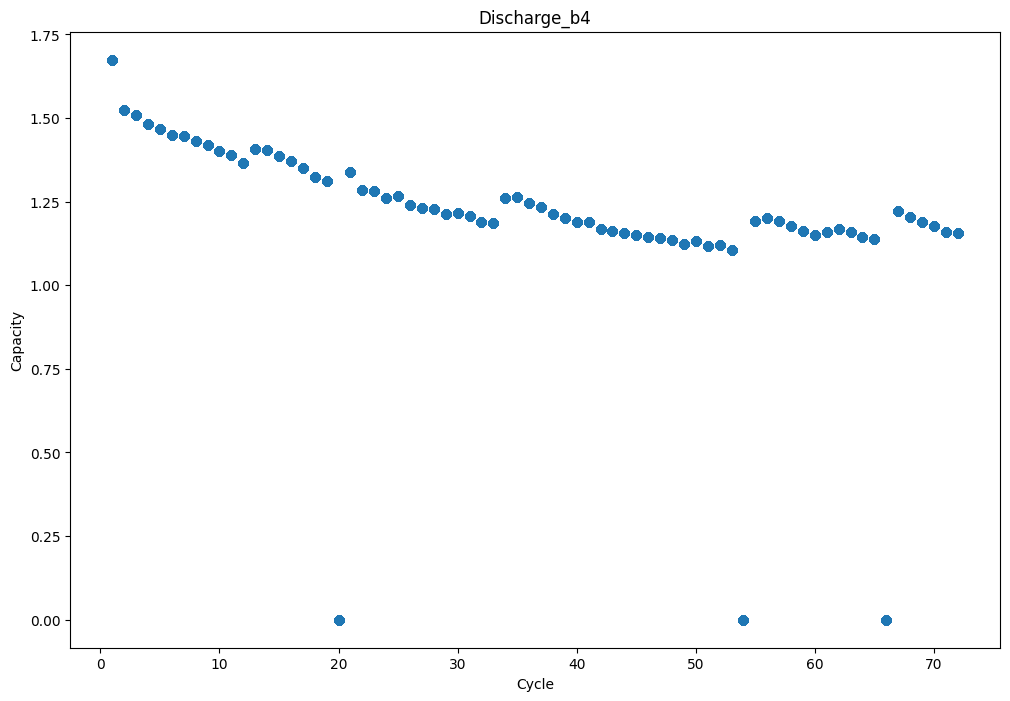

In [ ]:
plt.figure(figsize=(12,8))
plt.scatter(b7['cycle'],b7['capacity'])
plt.ylabel('Capacity')
plt.xlabel('Cycle')
plt.title('Discharge_b4')
plt.show()

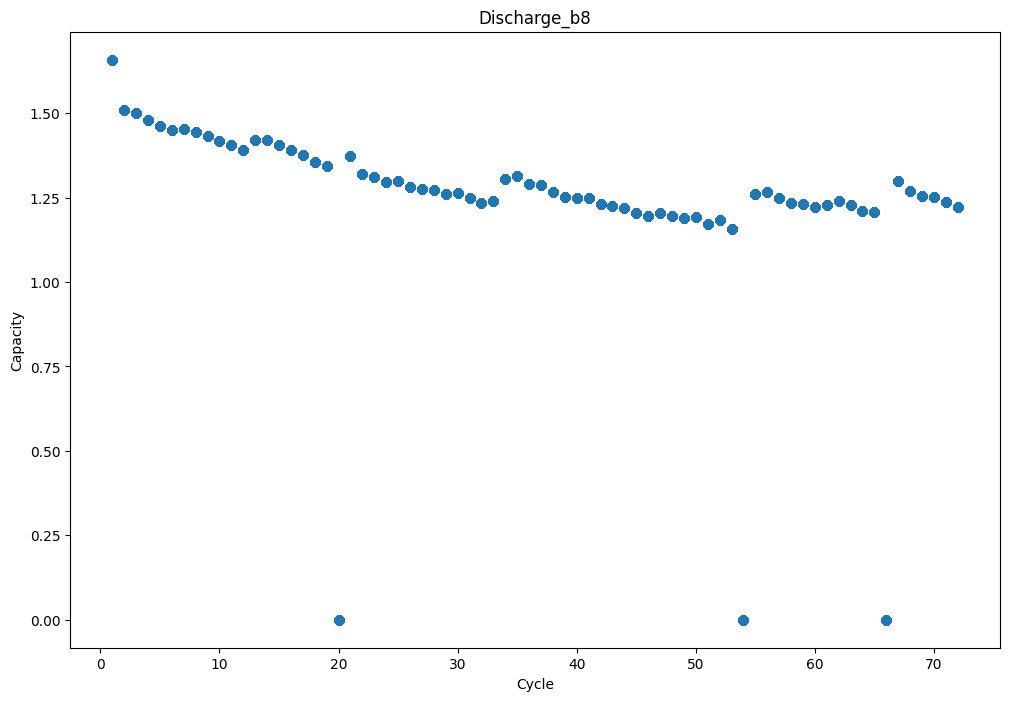

In [ ]:
plt.figure(figsize=(12,8))
plt.scatter(b8['cycle'],b8['capacity'])
plt.ylabel('Capacity')
plt.xlabel('Cycle')
plt.title('Discharge_b8')
plt.show()

Visualization of SOH vs Discharge Cycle

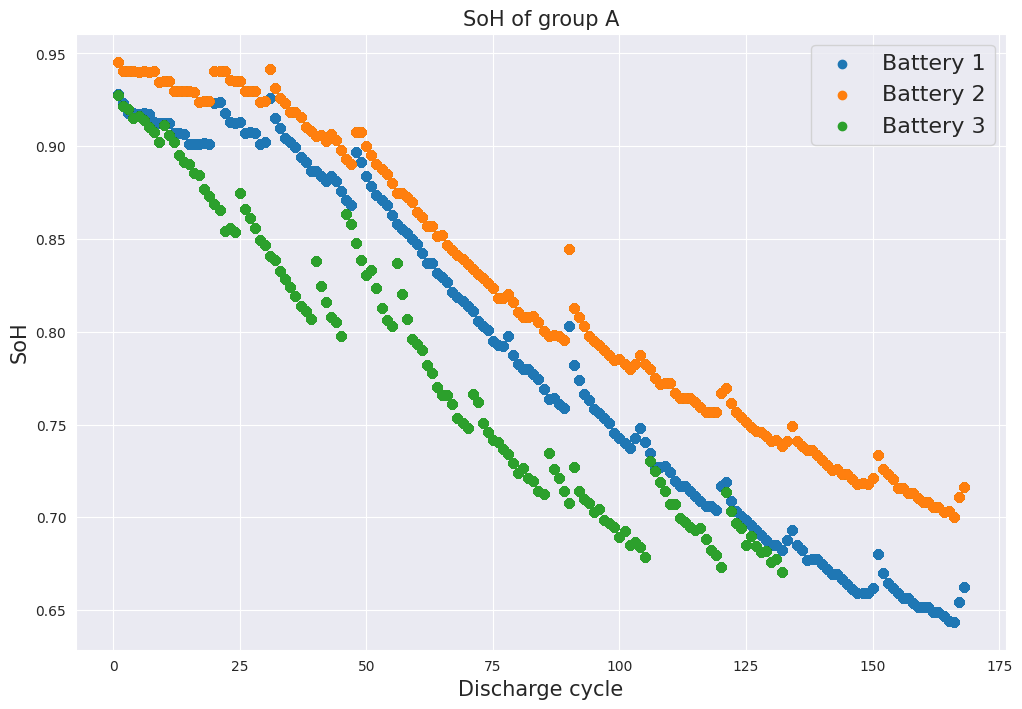

In [ ]:
sns.set_style("darkgrid")
plt.figure(figsize=(12, 8))
plt.scatter(b1['cycle'], b1['SOH'],label='Battery 1')
plt.scatter(b2['cycle'], b2['SOH'],label='Battery 2')
plt.scatter(b3['cycle'], b3['SOH'],label='Battery 3')
plt.legend(prop={'size': 16})
plt.ylabel('SoH', fontsize = 15)
plt.xlabel('Discharge cycle', fontsize = 15)
plt.title('SoH of group A', fontsize = 15)
plt.show()

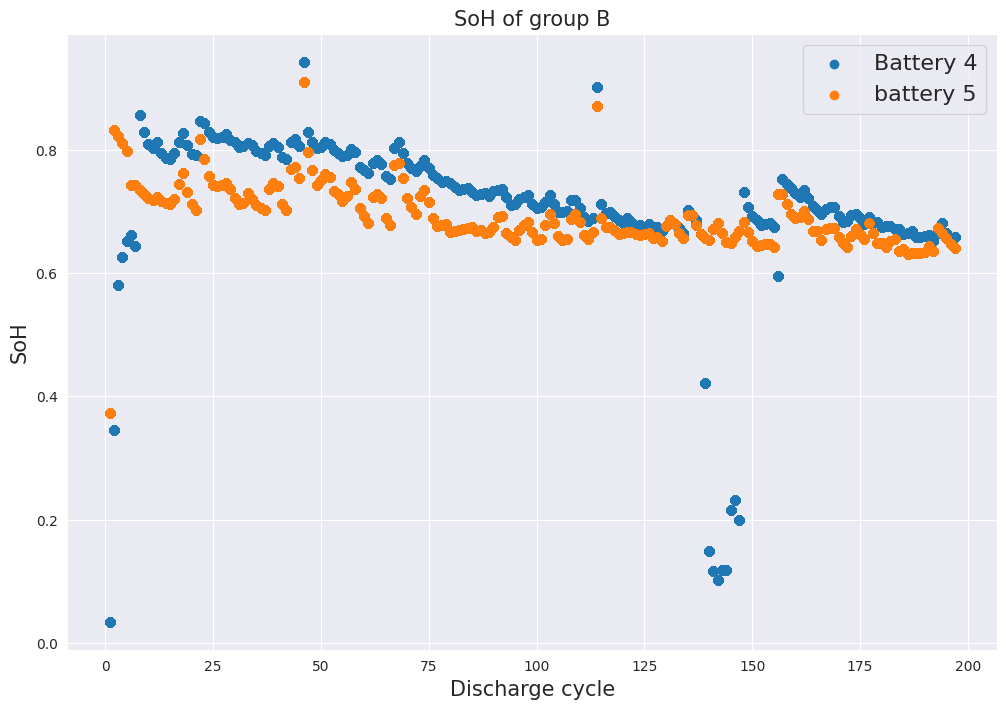

In [ ]:
sns.set_style("darkgrid")
plt.figure(figsize=(12, 8))

plt.scatter(b4['cycle'], b4['SOH'],label='Battery 4')
plt.scatter(b5['cycle'], b5['SOH'],label='battery 5')

plt.legend(prop={'size': 16})

plt.ylabel('SoH', fontsize = 15)
plt.xlabel('Discharge cycle', fontsize = 15)
plt.title('SoH of group B', fontsize = 15)
plt.show()

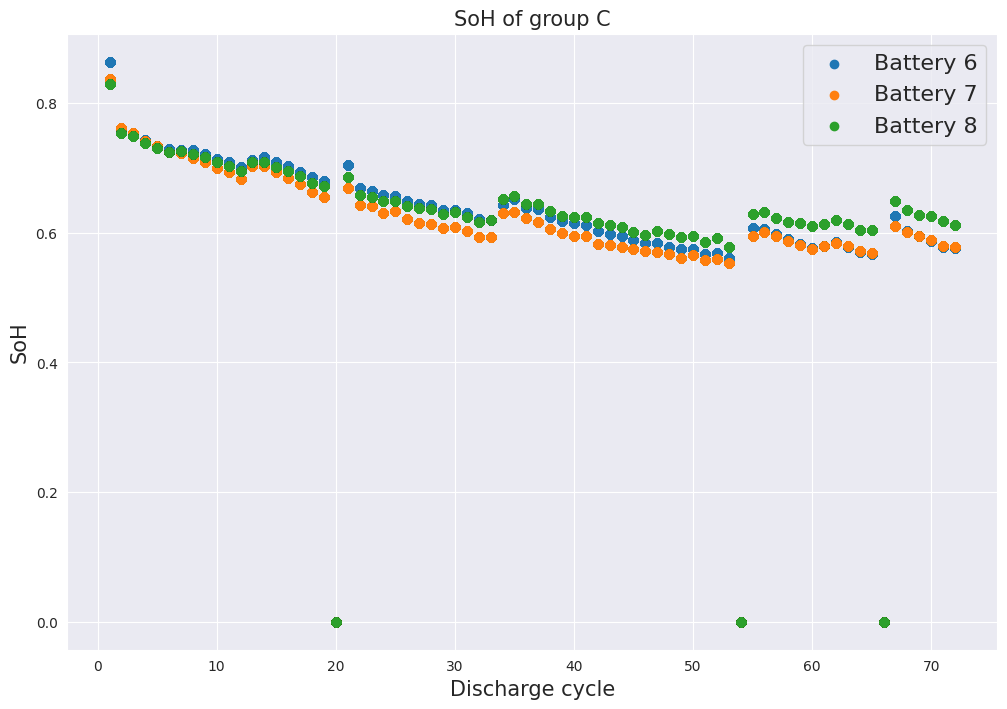

In [ ]:
sns.set_style("darkgrid")
plt.figure(figsize=(12, 8))

plt.scatter(b6['cycle'], b6['SOH'],label='Battery 6')
plt.scatter(b7['cycle'], b7['SOH'],label='Battery 7')
plt.scatter(b8['cycle'], b8['SOH'],label='Battery 8')
plt.legend(prop={'size': 16})
plt.ylabel('SoH', fontsize = 15)
plt.xlabel('Discharge cycle', fontsize = 15)
plt.title('SoH of group C', fontsize = 15)
plt.show()

## ML Model

In [ ]:
print("SOH range:", b1['SOH'].min(), "to", b1['SOH'].max())
print("Feature columns:", b1.columns)
print(b1.head())


SOH range: 0.643726261 to 0.928243711
Feature columns: Index(['terminal_voltage', 'terminal_current', 'temperature', 'charge_current',
       'charge_voltage', 'time', 'capacity', 'cycle', 'SOH'],
      dtype='object')
   terminal_voltage  terminal_current  temperature  charge_current  \
0          4.191492         -0.004902    24.330034         -0.0006   
1          4.190749         -0.001478    24.325993         -0.0006   
2          3.974871         -2.012528    24.389085         -1.9982   
3          3.951717         -2.013979    24.544752         -1.9982   
4          3.934352         -2.011144    24.731385         -1.9982   

   charge_voltage    time  capacity  cycle       SOH  
0           0.000   0.000  1.856487      1  0.928244  
1           4.206  16.781  1.856487      1  0.928244  
2           3.062  35.703  1.856487      1  0.928244  
3           3.030  53.781  1.856487      1  0.928244  
4           3.011  71.922  1.856487      1  0.928244  


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

features = ['terminal_voltage', 'terminal_current', 'temperature',
            'charge_current', 'charge_voltage', 'cycle']

X = b1[features]
y = b1['SOH']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False)

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))


MAE: 0.03163637576912359
R²: -2.42740829440491


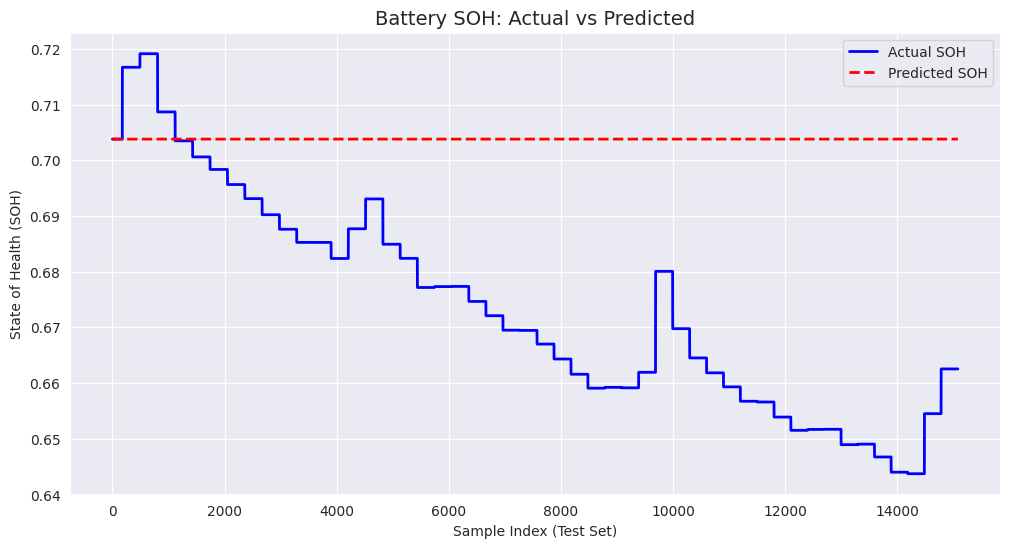

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual SOH', color='blue', linewidth=2)
plt.plot(y_pred, label='Predicted SOH', color='red', linestyle='--', linewidth=2)
plt.title('Battery SOH: Actual vs Predicted', fontsize=14)
plt.xlabel('Sample Index (Test Set)')
plt.ylabel('State of Health (SOH)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ====== Train-Test Split ======
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, shuffle=False)

# ====== Model Training ======
model = LinearRegression()
model.fit(X_train, y_train)

# ====== Prediction ======
y_pred = model.predict(X_test)

# ====== Model Evaluation ======
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results:")
print(f"Mean Absolute Error (MAE): {mae:.5f}")
print(f"R² Score: {r2:.5f}")


🔹 Linear Regression Results:
Mean Absolute Error (MAE): 0.03024
R² Score: -2.22200


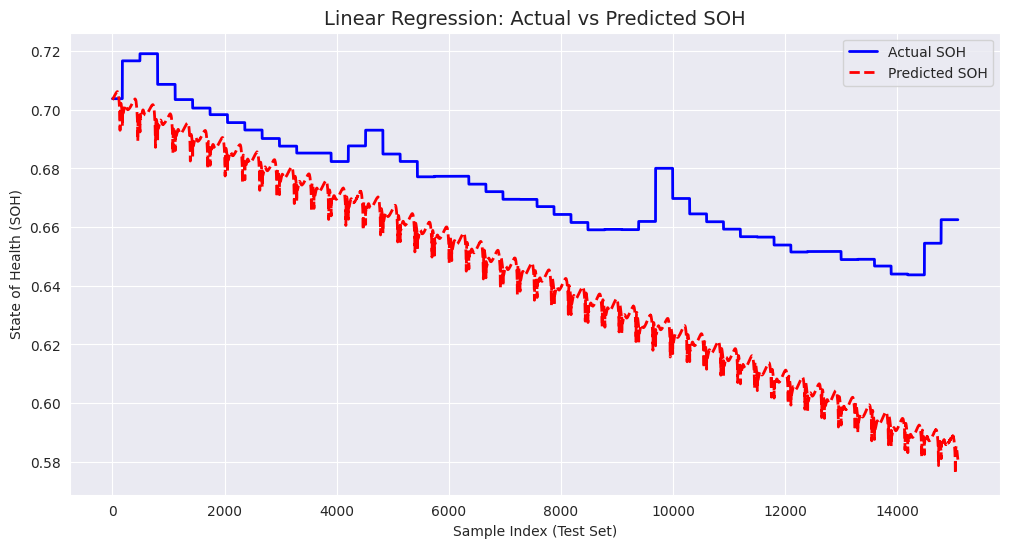

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual SOH', color='blue', linewidth=2)
plt.plot(y_pred, label='Predicted SOH', color='red', linestyle='--', linewidth=2)
plt.title('Linear Regression: Actual vs Predicted SOH', fontsize=14)
plt.xlabel('Sample Index (Test Set)')
plt.ylabel('State of Health (SOH)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score ,mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
import glob

# Load all discharge SOH CSV files
path = '/content/drive/MyDrive/SOH Dataset/*.csv'
files = glob.glob(path)

# Read and combine all files
dataset = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

print("Combined dataset shape:", dataset.shape)


Combined dataset shape: (303123, 9)


In [ ]:
# Select input features and target
features = ['terminal_voltage', 'terminal_current', 'temperature',
            'charge_current', 'charge_voltage', 'cycle']
target = 'SOH'

X = dataset[features].values
y = dataset[target].values.reshape(-1, 1)

# Normalize data (important for LSTM)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)


In [ ]:
def create_sequences(X, y, time_steps=10):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])
    return np.array(X_seq), np.array(y_seq)

time_steps = 10
X_seq, y_seq = create_sequences(X_scaled, y_scaled, time_steps)

# Train-Test Split (no shuffle for time order)
split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (242490, 10, 6) Test shape: (60623, 10, 6)


In [ ]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 10, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,137 (121.63 KB)

 Trainable params: 31,137 (121.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
3789/3789 ━━━━━━━━━━━━━━━━━━━━ 69s 17ms/step - loss: 0.0133 - val_loss: 0.0125
Epoch 2/50
3789/3789 ━━━━━━━━━━━━━━━━━━━━ 77s 16ms/step - loss: 0.0038 - val_loss: 0.0177
Epoch 3/50
3789/3789 ━━━━━━━━━━━━━━━━━━━━ 62s 16ms/step - loss: 0.0029 - val_loss: 0.0114
Epoch 4/50
3789/3789 ━━━━━━━━━━━━━━━━━━━━ 81s 16ms/step - loss: 0.0025 - val_loss: 0.0132
Epoch 5/50
3789/3789 ━━━━━━━━━━━━━━━━━━━━ 80s 16ms/step - loss: 0.0024 - val_loss: 0.0152
Epoch 6/50
3789/3789 ━━━━━━━━━━━━━━━━━━━━ 83s 16ms/step - loss: 0.0024 - val_loss: 0.0133
Epoch 7/50
3789/3789 ━━━━━━━━━━━━━━━━━━━━ 61s 16ms/step - loss: 0.0021 - val_loss: 0.0142
Epoch 8/50
3789/3789 ━━━━━━━━━━━━━━━━━━━━ 60s 16ms/step - loss: 0.0019 - val_loss: 0.0117
Epoch 9/50
3789/3789 ━━━━━━━━━━━━━━━━━━━━ 60s 16ms/step - loss: 0.0020 - val_loss: 0.0126
Epoch 10/50
3789/3789 ━━━━━━━━━━━━━━━━━━━━ 63s 17ms/step - loss: 0.0017 - val_loss: 0.0133
Epoch 11/50
3789/3789 ━━━━━━━━━━━━━━━━━━━━ 61s 16ms/step - loss: 0.0018 - val_loss: 0.0145
Epoch 12

In [ ]:
# Predictions
y_pred = model.predict(X_test)

# Inverse scale to original SOH values
y_test_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_pred)

# Metrics
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")
print(f"RMSE : {rmse :.4f}")

# Actual vs Predicted Line Plot
plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label='Actual SOH', color='blue')
plt.plot(y_pred_inv, label='Predicted SOH', color='red', linestyle='--')
plt.title('LSTM Model: Actual vs Predicted SOH', fontsize=14)
plt.xlabel('Sample Index')
plt.ylabel('State of Health (SOH)')
plt.legend()
plt.grid(True)
plt.show()

#  Scatter Plot
plt.figure(figsize=(6,6))
plt.scatter(y_test_inv, y_pred_inv, alpha=0.6, color='purple')
plt.plot([y_test_inv.min(), y_test_inv.max()], [y_test_inv.min(), y_test_inv.max()], 'r--')
plt.title('LSTM SOH Prediction', fontsize=14)
plt.xlabel('Actual SOH')
plt.ylabel('Predicted SOH')
plt.grid(True)
plt.show()
